In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

In [ ]:
df = pd.read_csv("dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (30000, 12)


In [ ]:
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [ ]:
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']

Data Types:
patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
readmitted_30_days        object
dtype: object


In [ ]:
print(df.isnull().sum())

patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


In [ ]:
print("Rows, Columns:", df.shape)
print("\nDataset Info:")
df.info()

Rows, Columns: (30000, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [ ]:
print(df.columns.tolist())

['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']


In [ ]:
target = "readmitted_30_days"

print(df[target].value_counts())

readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [ ]:
df[target] = df[target].map({"No": 0, "Yes": 1})

print(df[target].value_counts())

readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=[target, "patient_id"])
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 10)
Target: (30000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24000, 10)
Testing data: (6000, 10)


In [ ]:
print("Numerical columns:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

Numerical columns:
['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

Categorical columns:
['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [ ]:
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("logistic_regression", LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred[:10])
print("Probabilities:", y_prob[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [0.2070324  0.16252125 0.0633526  0.15471272 0.22770915 0.09386209
 0.14183627 0.28635657 0.19467901 0.07101161]


In [ ]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.5373


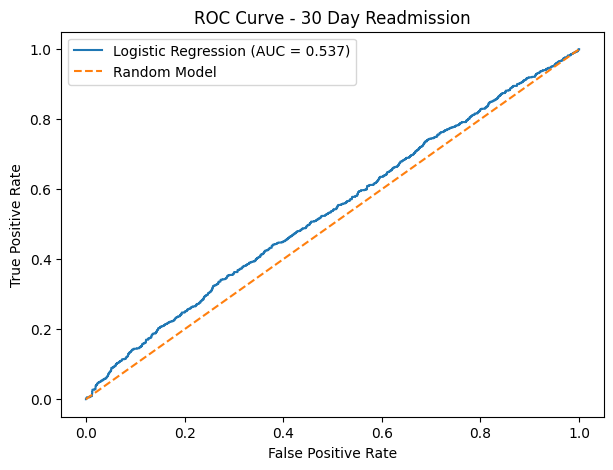

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30 Day Readmission")
plt.legend()
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[5265    0]
 [ 735    0]]


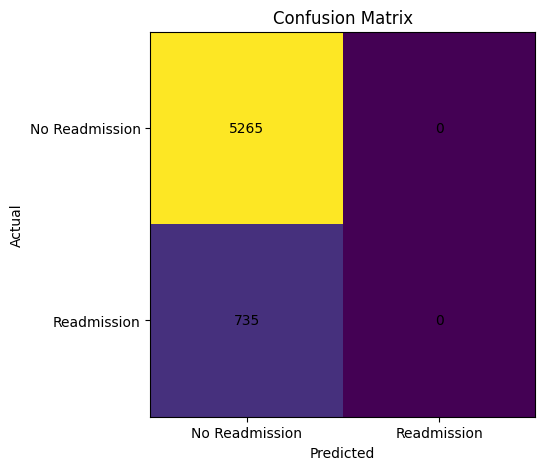

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.xticks([0, 1], ["No Readmission", "Readmission"])
plt.yticks([0, 1], ["No Readmission", "Readmission"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Readmission", "Readmission"]
))

                precision    recall  f1-score   support

No Readmission       0.88      1.00      0.93      5265
   Readmission       0.00      0.00      0.00       735

      accuracy                           0.88      6000
     macro avg       0.44      0.50      0.47      6000
  weighted avg       0.77      0.88      0.82      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 5265
False Positives: 0
False Negatives: 735
True Positives  : 0


In [ ]:
fpr_rate = fp / (fp + tn)
fnr_rate = fn / (fn + tp)

print("False Positive Rate :", round(fpr_rate, 4))
print("False Negative Rate :", round(fnr_rate, 4))

False Positive Rate : 0.0
False Negative Rate : 1.0


In [ ]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred)

    tn, fp, fn, tp = cm.ravel()

    print(
        f"Threshold: {threshold} | "
        f"FP: {fp} | FN: {fn} | TP: {tp} | TN: {tn}"
    )

Threshold: 0.3 | FP: 101 | FN: 714 | TP: 21 | TN: 5164
Threshold: 0.4 | FP: 16 | FN: 731 | TP: 4 | TN: 5249
Threshold: 0.5 | FP: 0 | FN: 735 | TP: 0 | TN: 5265
Threshold: 0.6 | FP: 0 | FN: 735 | TP: 0 | TN: 5265
Threshold: 0.7 | FP: 0 | FN: 735 | TP: 0 | TN: 5265


In [ ]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["logistic_regression"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient,Absolute_Coefficient
301,cat__blood_pressure_119/83,1.547897,1.547897
1183,cat__blood_pressure_147/97,1.518803,1.518803
864,cat__blood_pressure_137/88,1.513280,1.513280
399,cat__blood_pressure_122/88,1.494244,1.494244
809,cat__blood_pressure_135/95,1.458217,1.458217
1252,cat__blood_pressure_150/73,1.398199,1.398199
565,cat__blood_pressure_127/99,1.338497,1.338497
597,cat__blood_pressure_129/100,1.328852,1.328852
1474,cat__blood_pressure_157/78,1.266671,1.266671
1435,cat__blood_pressure_156/70,1.257330,1.257330


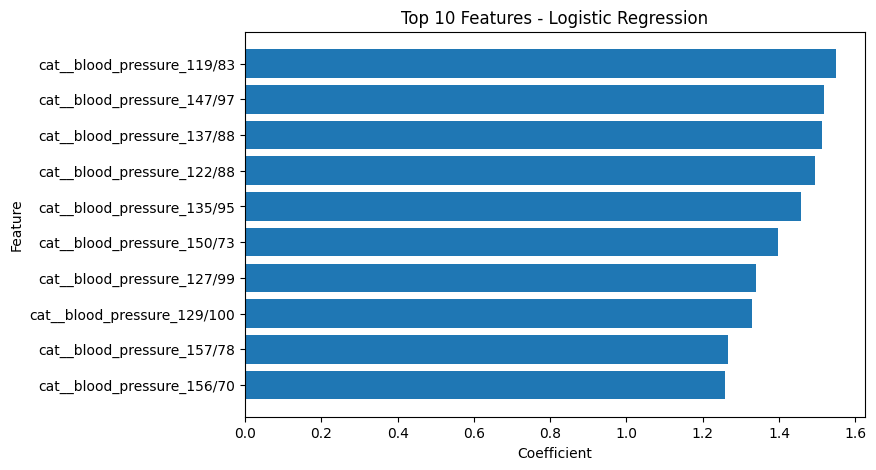

In [ ]:
top_features = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features - Logistic Regression")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
print("ROC-AUC Score:", round(auc, 4))
print("Accuracy:", round((tp + tn) / (tp + tn + fp + fn), 4))
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("True Negatives:", tn)

ROC-AUC Score: 0.5373
Accuracy: 0.8775
False Positives: 0
False Negatives: 735
True Positives: 0
True Negatives: 5265
